# Random walk

A random walk is the canonical non-stationary series: each value is the previous one plus a random step, optionally nudged by a constant drift. It is the process behind the *naive* forecast (tomorrow ≈ today), a first model of efficient-market prices, and a useful stress test for whether a pipeline handles trends and growing variance rather than assuming a stable mean.

::: {.callout-note}
## The model

$$y_t = y_{t-1} + \mu + \sigma\,\varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, 1)$$

- `drift` ($\mu$) — the constant step added each period; a deterministic trend.
- `volatility` ($\sigma$) — the standard deviation of the random step.
- `start_value` ($y_0$) — where every series begins.

Because steps accumulate, the variance grows with time — the series has no fixed mean to revert to.
:::

## Generate

Instantiate the generator and draw a few series. All outputs are long-format (`unique_id`, `ds`, `y`).

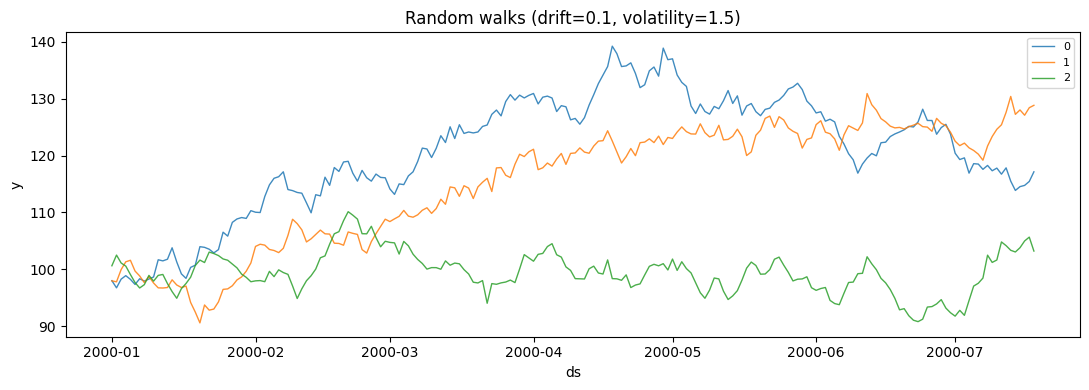

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast.generators import RandomWalkGenerator


def plot_panel(df, title):
    """Plot each series in a long-format panel on a shared axis."""
    fig, ax = plt.subplots(figsize=(11, 4))
    for uid in df["unique_id"].unique(maintain_order=True).to_list():
        series = df.filter(pl.col("unique_id") == uid)
        ax.plot(series["ds"], series["y"], linewidth=1, alpha=0.85, label=str(uid))
    ax.set(title=title, xlabel="ds", ylabel="y")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


generator = RandomWalkGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    drift=0.1,
    volatility=1.5,
    start_value=100.0,
    seed=42,
)
walks = generator.generate(n_series=3)
plot_panel(walks, "Random walks (drift=0.1, volatility=1.5)")

The three series share the same process but a different noise draw. They all start at 100 and trend gently upward — that shared pull is the drift — while wandering by an amount set by the volatility. Notice how they fan out over time: that spreading is the growing variance a random walk always produces.

## Control the process

`drift` sets the trend and `volatility` sets the noise. Holding volatility fixed, larger drift turns a flat wander into a clear trend.

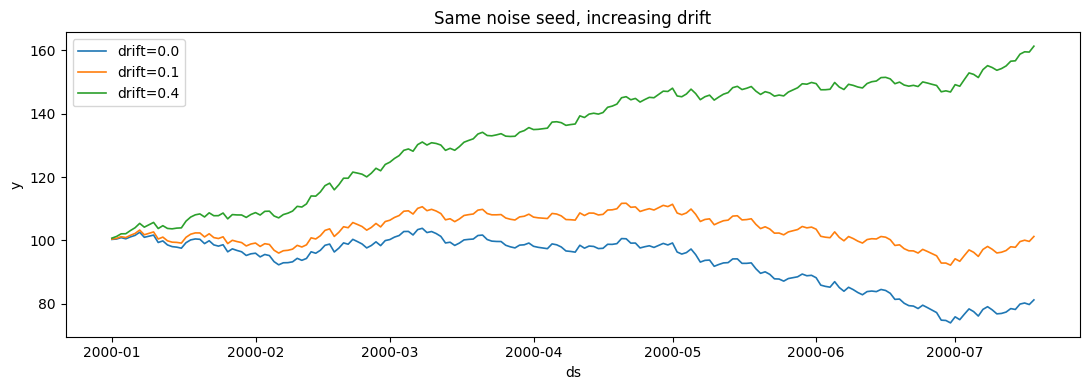

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
for drift in (0.0, 0.1, 0.4):
    series = RandomWalkGenerator(
        engine="polars",
        min_length=200,
        max_length=200,
        freq="D",
        drift=drift,
        volatility=1.0,
        start_value=100.0,
        seed=0,
    ).generate(n_series=1)
    ax.plot(series["ds"], series["y"], linewidth=1.2, label=f"drift={drift}")
ax.set(title="Same noise seed, increasing drift", xlabel="ds", ylabel="y")
ax.legend()
plt.tight_layout()
plt.show()

Sharing the seed isolates the effect: the wiggles are identical, but a larger drift lifts the whole path. Raise `volatility` instead and the paths would keep this trend while wandering further from it.

## Statistics by series

Summary statistics vary widely between series even from one generator — a direct consequence of the accumulating, unbounded variance.

In [ ]:
walks.group_by("unique_id").agg(
    pl.len().alias("count"),
    pl.col("y").min().round(2).alias("min"),
    pl.col("y").max().round(2).alias("max"),
    pl.col("y").mean().round(2).alias("mean"),
    pl.col("y").std().round(2).alias("std"),
).sort("unique_id")

unique_id,count,min,max,mean,std
cat,u32,f64,f64,f64,f64
"""0""",200,96.74,139.24,120.67,10.36
"""1""",200,90.58,130.9,115.29,10.56
"""2""",200,90.8,110.13,99.45,3.61


::: {.callout-tip}
## Related generators

- [Geometric Brownian motion](/synforecast/docs/generators/stochastic/geometric_brownian_motion.html) — a *multiplicative* random walk for strictly positive series like prices.
- [SARIMA](/synforecast/docs/generators/statistical/sarima.html) with `d=1` — a random walk with added autoregressive/moving-average structure.
- Add trend breaks or outliers with the [changepoints](/synforecast/docs/capabilities/changepoints.html) and [anomalies](/synforecast/docs/capabilities/anomalies.html) options.

Every parameter is documented in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::